# Projet Api Immo Lille 

In [1]:
#import utile pour le projet machine learning 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression


In [2]:
#création dataframe pandas 
df = pd.read_csv("../data/lille_2022.csv")

In [3]:
#Apreçu jeu de donné 
print(df.shape)
df.head()

(11354, 44)


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,prix_m2
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,0,1.0,Maison,NaN,82.0,5.0,S,NaN,70.0,2681.707317
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,2,2.0,Appartement,NaN,63.0,3.0,NaN,NaN,NaN,2936.507937
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,2,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN,inf
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN,inf
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN,inf


 3️⃣ Premier Filtrage :
 - logements à 4 pièces
 - colonnes utiles
 - me prix au m2 est déja integres 

In [4]:
df = df[df["Nombre pieces principales"] == 4 ]

colonnes_utiles = [
    "Surface reelle bati",
    "Nombre pieces principales",
    "Type local",
    "Surface terrain",
    "Nombre de lots",
    "Valeur fonciere"
]
df = df[colonnes_utiles]
df.head()

,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
23,92.0,4.0,Appartement,NaN,1,367000.0
26,70.0,4.0,Appartement,NaN,2,170000.0
58,105.0,4.0,Appartement,NaN,2,355300.0
62,120.0,4.0,Appartement,NaN,1,472500.0


In [5]:
# Séparer maisons / appartements
df_maisons = df[df['Type local'].str.lower().str.contains('maison')].copy()
df_apparts = df[df['Type local'].str.lower().str.contains('appartement')].copy()
# Nettoyage des NA sur les colonnes utilisées
# apres verffication, on change les lignes par des zeros 
cols = ['Surface reelle bati', 'Nombre pieces principales', 'Surface terrain', 'Nombre de lots','Valeur fonciere']
df_maisons = df_maisons[cols].dropna()
df_apparts['Surface terrain'] = df_apparts['Surface terrain'].fillna(0) 

# df_apparts = df_apparts[cols].dropna()

In [6]:
#pd.set_option('display.max_rows', None)  # Affiche toutes les lignes
df_apparts.info()
df_apparts
#print(df_apparts.isnull())

<class 'pandas.core.frame.DataFrame'>
Index: 435 entries, 23 to 11351
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Surface reelle bati        435 non-null    float64
 1   Nombre pieces principales  435 non-null    float64
 2   Type local                 435 non-null    object 
 3   Surface terrain            435 non-null    float64
 4   Nombre de lots             435 non-null    int64  
 5   Valeur fonciere            435 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 23.8+ KB


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
23,92.0,4.0,Appartement,0.0,1,367000.0
26,70.0,4.0,Appartement,0.0,2,170000.0
58,105.0,4.0,Appartement,0.0,2,355300.0
62,120.0,4.0,Appartement,0.0,1,472500.0
113,71.0,4.0,Appartement,0.0,1,229900.0
...,...,...,...,...,...,...
11267,112.0,4.0,Appartement,0.0,2,500000.0
11271,81.0,4.0,Appartement,0.0,1,173250.0
11316,103.0,4.0,Appartement,0.0,2,381500.0
11328,117.0,4.0,Appartement,0.0,2,627000.0


In [7]:
#pd.set_option('display.max_rows', None)  # Affiche toutes les lignes
df_maisons.info()
df_maisons

#print(df_maisons.isnull())

<class 'pandas.core.frame.DataFrame'>
Index: 340 entries, 18 to 11353
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Surface reelle bati        340 non-null    float64
 1   Nombre pieces principales  340 non-null    float64
 2   Surface terrain            340 non-null    float64
 3   Nombre de lots             340 non-null    int64  
 4   Valeur fonciere            340 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 15.9 KB


,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,121.0,0,305000.0
65,64.0,4.0,127.0,0,226900.0
161,70.0,4.0,192.0,0,205890.0
168,62.0,4.0,96.0,0,159500.0
176,72.0,4.0,135.0,0,259900.0
...,...,...,...,...,...
11091,120.0,4.0,100.0,0,320000.0
11129,110.0,4.0,225.0,0,412000.0
11235,86.0,4.0,171.0,0,230000.0
11352,72.0,4.0,278.0,0,200000.0


In [8]:
#detect nan et zero et les renvoie dans un dataframe
def detect_nan_and_zeros(df: pd.DataFrame) -> pd.DataFrame:
    # On ne garde que les colonnes numériques
    num_cols = df.select_dtypes(include='number').columns
    results = []
    for col in num_cols:
        n_nan = df[col].isna().sum()
        n_zero = (df[col] == 0).sum()
        results.append({
            'column': col,
            'n_nan': n_nan,
            'n_zero': n_zero
        })
    return pd.DataFrame(results)

df_test_maisons=detect_nan_and_zeros(df_maisons)
df_test_apparts=detect_nan_and_zeros(df_apparts)


In [9]:
df_test_maisons

,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,0
3,Nombre de lots,0,340
4,Valeur fonciere,0,0


In [10]:
df_test_apparts

,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,386
3,Nombre de lots,0,49
4,Valeur fonciere,0,0


In [11]:
# on fait le champs prix_m2 por les maisons et appartements
# Calculer le prix_m2
df_maisons['prix_m2'] = df_maisons['Valeur fonciere'] / df_maisons['Surface reelle bati']

df_apparts['prix_m2'] = df_apparts['Valeur fonciere'] / df_apparts['Surface reelle bati']

df_maisons

,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
18,165.0,4.0,121.0,0,305000.0,1848.484848
65,64.0,4.0,127.0,0,226900.0,3545.312500
161,70.0,4.0,192.0,0,205890.0,2941.285714
168,62.0,4.0,96.0,0,159500.0,2572.580645
176,72.0,4.0,135.0,0,259900.0,3609.722222
...,...,...,...,...,...,...
11091,120.0,4.0,100.0,0,320000.0,2666.666667
11129,110.0,4.0,225.0,0,412000.0,3745.454545
11235,86.0,4.0,171.0,0,230000.0,2674.418605
11352,72.0,4.0,278.0,0,200000.0,2777.777778


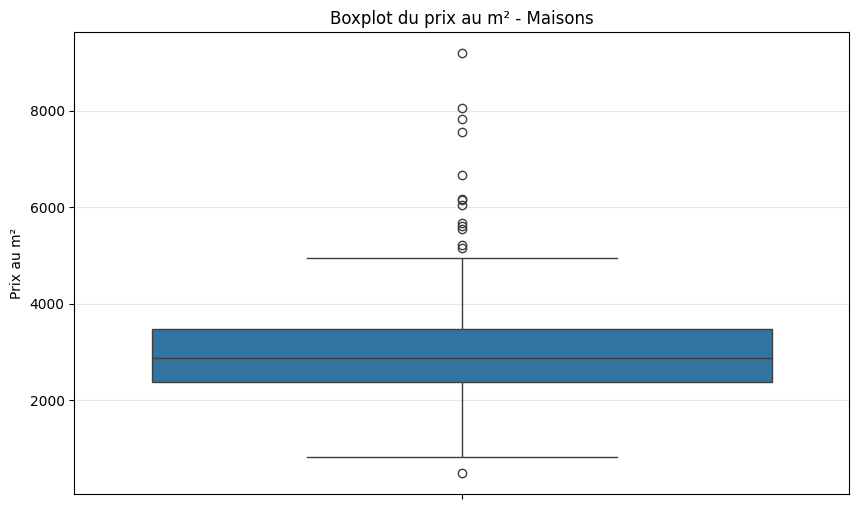

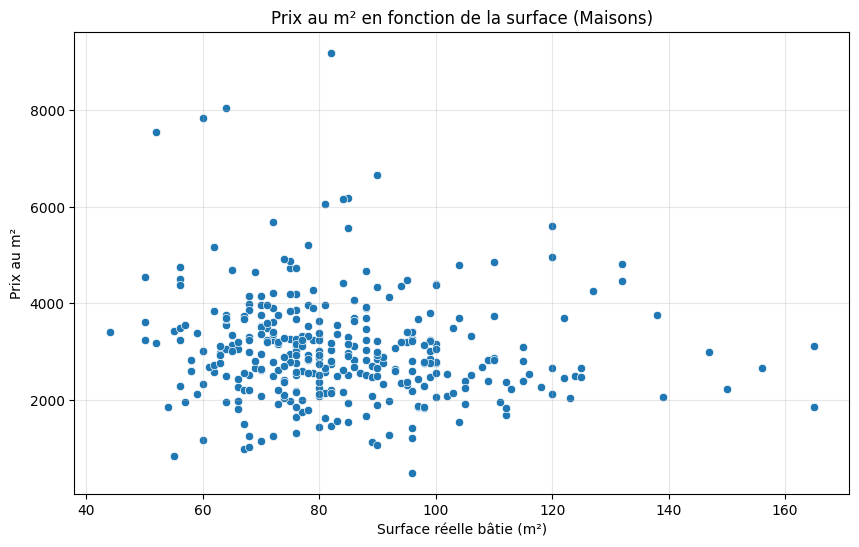

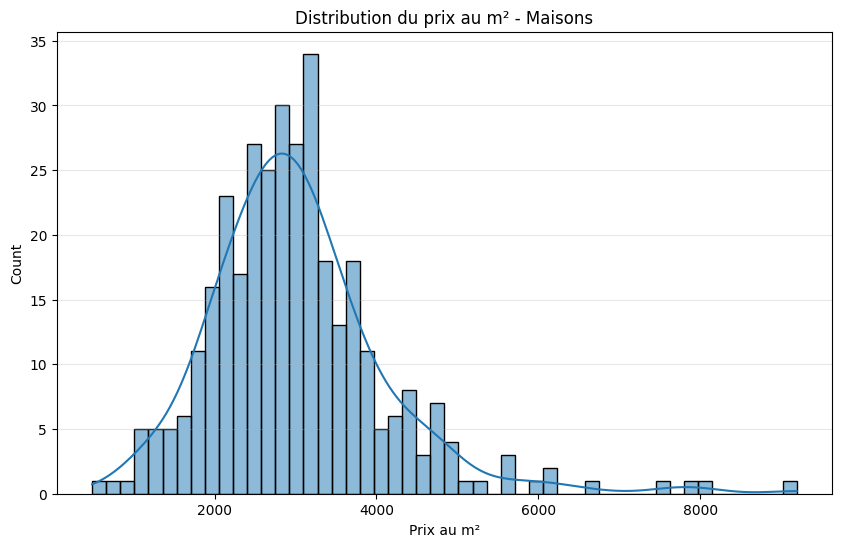

In [12]:
# On suppose que ton DataFrame filtré pour les maisons est dans `df_maisons`
# Et que la variable cible est `prix_m2`

plt.figure(figsize=(10, 6))

# 1) Boxplot pour visualiser les valeurs extrêmes
sns.boxplot(data=df_maisons, y='prix_m2')
plt.title('Boxplot du prix au m² - Maisons')
plt.ylabel('Prix au m²')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2) Nuage de points entre surface et prix_m2 pour voir la tendance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_maisons, x='Surface reelle bati', y='prix_m2')
plt.title('Prix au m² en fonction de la surface (Maisons)')
plt.xlabel('Surface réelle bâtie (m²)')
plt.ylabel('Prix au m²')
plt.grid(alpha=0.3)
plt.show()

# 3) Distribution des prix au m²
plt.figure(figsize=(10, 6))
sns.histplot(df_maisons['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² - Maisons')
plt.xlabel('Prix au m²')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

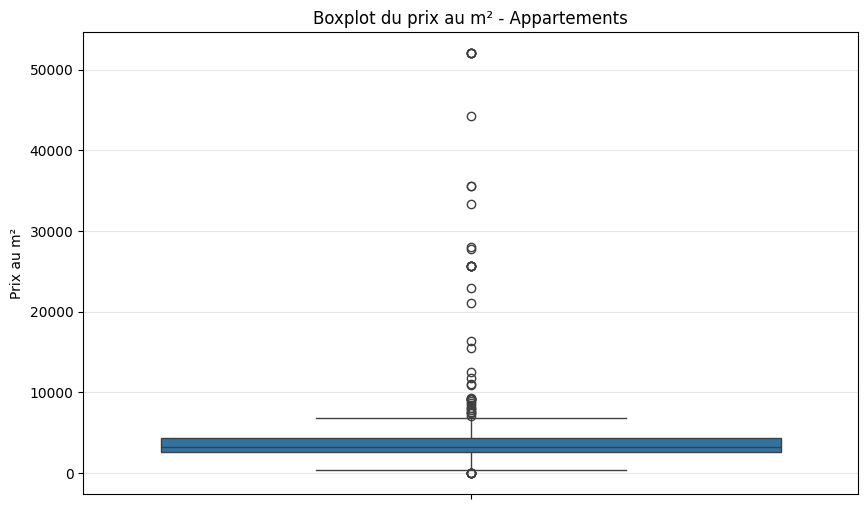

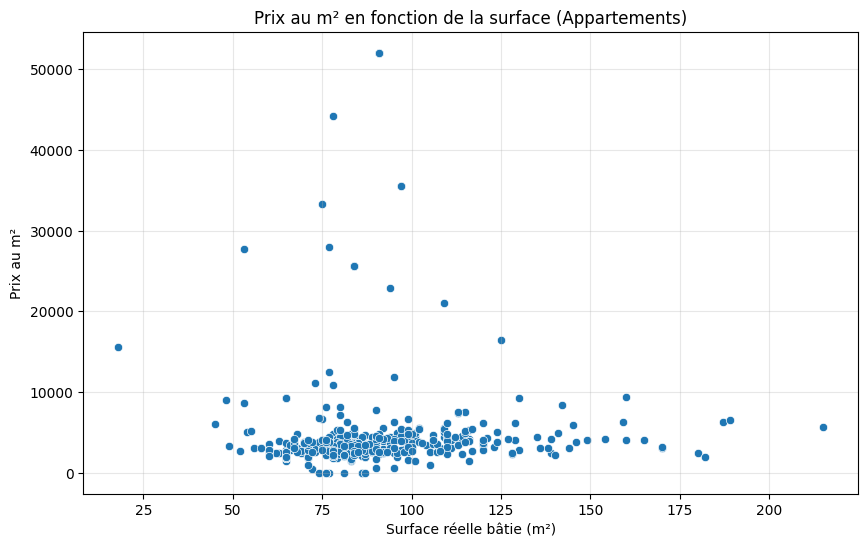

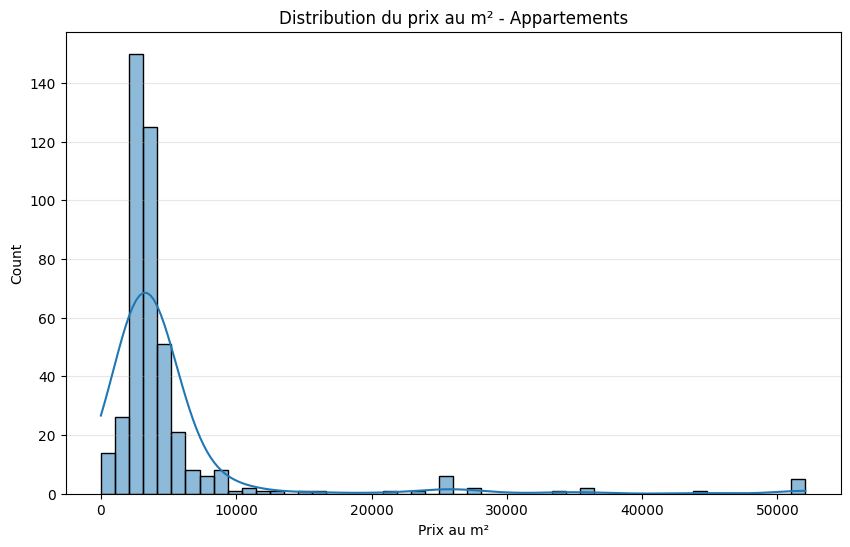

In [13]:
# On suppose que ton DataFrame filtré pour les appartements est dans `df_appartements`

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_apparts, y='prix_m2')
plt.title('Boxplot du prix au m² - Appartements')
plt.ylabel('Prix au m²')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_apparts, x='Surface reelle bati', y='prix_m2')
plt.title('Prix au m² en fonction de la surface (Appartements)')
plt.xlabel('Surface réelle bâtie (m²)')
plt.ylabel('Prix au m²')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_apparts['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² - Appartements')
plt.xlabel('Prix au m²')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [14]:
# Detection outliers

def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return lower_bound, upper_bound, outliers

lb, ub, outliers_app = detect_outliers(df_apparts, "prix_m2")
print(f"{len(outliers_app)} valeurs aberrantes détectées sur prix_m2")
lb, ub, outliers_app = detect_outliers(df_apparts, "Surface reelle bati")
print(f"{len(outliers_app)} valeurs aberrantes détectées sur Surface reelle bati")

lb, ub, outliers_app = detect_outliers(df_maisons, "prix_m2")
print(f"{len(outliers_app)} valeurs aberrantes détectées sur prix_m2")
lb, ub, outliers_app = detect_outliers(df_maisons, "Surface terrain")
print(f"{len(outliers_app)} valeurs aberrantes détectées sur Surface terrain")
lb, ub, outliers_app = detect_outliers(df_maisons, "Surface reelle bati")
print(f"{len(outliers_app)} valeurs aberrantes détectées sur Surface reelle bati")


49 valeurs aberrantes détectées sur prix_m2
25 valeurs aberrantes détectées sur Surface reelle bati
14 valeurs aberrantes détectées sur prix_m2
12 valeurs aberrantes détectées sur Surface terrain
9 valeurs aberrantes détectées sur Surface reelle bati


In [15]:
# ===================
# Nettoyage des valeurs aberrantes
# ===================
colonnes_a_nettoyer = ["prix_m2", "Surface reelle bati", "Surface terrain"]

for col in colonnes_a_nettoyer:
    lower_bound, upper_bound, _ = detect_outliers(df_maisons, col)
    df_maisons = df_maisons[~((df_maisons[col] < lower_bound) | (df_maisons[col] > upper_bound))]
    lower_bound, upper_bound, _ = detect_outliers(df_apparts, col)
    df_apparts = df_apparts[~((df_apparts[col] < lower_bound) | (df_apparts[col] > upper_bound))]

In [16]:
# changement df_maisons et df_apparts pour supprimer nombres pieces principales et nombre de lots 
colonnes_utiles = [
    "Surface reelle bati",
    "Surface terrain",
    "Nombre de lots",
    "Valeur fonciere",
    "prix_m2"
]

df_maisons = df_maisons[colonnes_utiles]
df_apparts = df_apparts[colonnes_utiles]


df_maisons.corr()

,Surface reelle bati,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
Surface reelle bati,1.000000,0.263112,NaN,0.552354,-0.047986
Surface terrain,0.263112,1.000000,NaN,0.255819,0.126819
Nombre de lots,NaN,NaN,NaN,NaN,NaN
Valeur fonciere,0.552354,0.255819,NaN,1.000000,0.785234
prix_m2,-0.047986,0.126819,NaN,0.785234,1.000000


In [17]:
df_apparts.corr()

,Surface reelle bati,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
Surface reelle bati,1.000000,NaN,0.040448,0.673833,0.293680
Surface terrain,NaN,NaN,NaN,NaN,NaN
Nombre de lots,0.040448,NaN,1.000000,0.109565,0.105080
Valeur fonciere,0.673833,NaN,0.109565,1.000000,0.892037
prix_m2,0.293680,NaN,0.105080,0.892037,1.000000


In [18]:
# ===================
# Définir les features (X) et la cible (y)
# ===================
features_maison = ["Surface reelle bati", "Surface terrain"]
features_apparts = ["Surface reelle bati",  "Nombre de lots"]

target = "prix_m2"

# Tu peux ajuster ici si "Valeur fonciere" est pertinente dans ton X :
# Pour le moment, on l'utilise car l'énoncé le mentionne.
# Si ce n'est pas voulu, retire-la.


X_maisons = df_maisons[features_maison]
y_maisons = df_maisons['prix_m2']

X_apparts = df_apparts[features_apparts]
y_apparts = df_apparts['prix_m2']


## A partir d'ici pour plus de clarté et de lisibilité on va séparer maison et apparts pour la création de leurs modèles on commence par maison 

### Model Maisons 

In [19]:
# # Visualisation comparée des scores RMSE et R2
# results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
# fig, ax = plt.subplots(1, 2, figsize=(14,6))

# sns.barplot(data=results_df, x="Model", y="RMSE", ax=ax[0], palette="Blues_d")
# ax[0].set_title("RMSE des modèles")
# ax[0].set_ylabel("RMSE")
# ax[0].set_xlabel("Modèle")

# sns.barplot(data=results_df, x="Model", y="R2", ax=ax[1], palette="Greens_d")
# ax[1].set_title("Coefficient de détermination R2")
# ax[1].set_ylabel("R2")
# ax[1].set_xlabel("Modèle")

# plt.suptitle("Comparaison des performances des modèles")
# plt.tight_layout()
# plt.show()

In [ ]:
def run_all_models(
    df: pd.DataFrame,
    features: list,
    target: str,
    title: str = "Comparaison de tous les modèles"
):
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # === Modèles d'arbre + XGBoost ===
    param_grids = {
        "Decision Tree": {
            "model__max_depth": [3, 5, None],
            "model__min_samples_split": [2, 10]
        },
        "Random Forest": {
            "model__n_estimators": [50, 100],
            "model__max_depth": [3, None]
        },
        "XGBoost": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.01, 0.1]
        }
    }
    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, verbosity=0)
    }

    results = {}
    best_pipelines = {}

    for name, model in models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring="r2", n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test)
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
        best_pipelines[name] = best_model

        print(f"=== {name} === (best params: {grid.best_params_})")
        print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.3f}\n")

    # === Modèle linéaire + SelectKBest ===
    pipe_lin = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression)),
        ("model", LinearRegression())
    ])
    param_grid_lin = {"select__k": list(range(1, len(features) + 1))}

    grid_lin = GridSearchCV(pipe_lin, param_grid_lin, cv=5, scoring="r2", n_jobs=-1)
    grid_lin.fit(X_train, y_train)
    best_model_lin = grid_lin.best_estimator_

    y_pred_lin = best_model_lin.predict(X_test)
    rmse_lin = mean_squared_error(y_test, y_pred_lin, squared=False)
    mae_lin = mean_absolute_error(y_test, y_pred_lin)
    r2_lin = r2_score(y_test, y_pred_lin)

    results["Linear + SelectKBest"] = {"RMSE": rmse_lin, "MAE": mae_lin, "R2": r2_lin}
    best_pipelines["Linear + SelectKBest"] = best_model_lin

    print(f"=== Linear Regression + SelectKBest === (best k={grid_lin.best_params_['select__k']})")
    print(f"RMSE: {rmse_lin:.2f}, MAE: {mae_lin:.2f}, R2: {r2_lin:.3f}\n")

    # === Graphiques comparatifs ===
    results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    sns.barplot(data=results_df, x="Model", y="RMSE", ax=ax[0], palette="Blues_d")
    ax[0].set_title("Comparaison des RMSE")
    sns.barplot(data=results_df, x="Model", y="R2", ax=ax[1], palette="Greens_d")
    ax[1].set_title("Comparaison des R²")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    return results_df, best_pipelines


In [21]:
features_maison = ["Surface reelle bati", "Surface terrain"]
features_apparts = ["Surface reelle bati",  "Nombre de lots"]
target = "prix_m2"
results_df, best_pipelines = run_all_models(df_maisons, features_maison, target)

TypeError: got an unexpected keyword argument 'squared'